# Анализ рекламных кампаний

## Описание задания

Необходимо провести анализ данных по рекламным кампаниям и оценить эффективность объявлений на основе ключевых метрик.

## Описание данных

| Колонка | Описание |
|---|---|
| `ad_id` | Идентификатор объявления |
| `xyz_campaign_id` | Идентификатор рекламной кампании в базе компании X |
| `fb_campaign_id` | Идентификатор кампании в Facebook |
| `age` | Возрастная группа, которой показывалась реклама |
| `gender` | Пол пользователей, которым показывалась реклама |
| `interest` | Код категории интереса пользователя |
| `impressions` | Количество показов объявления |
| `clicks` | Количество кликов по объявлению |
| `spent` | Сумма, потраченная на показ объявления |
| `total_conversion` | Количество пользователей, заинтересовавшихся продуктом после просмотра рекламы |
| `approved_conversion` | Количество пользователей, купивших продукт после просмотра рекламы |

## План анализа

### 1. Загрузка и первичный обзор данных

Необходимо загрузить датасет и изучить его структуру:

- количество наблюдений;
- количество столбцов;
- типы данных;
- наличие пропущенных значений;
- уникальные значения в колонках.

### 2. Анализ показов рекламы

Построить распределение количества показов `impressions` для каждого объявления.

Так как значения показов могут сильно различаться, необходимо предварительно прологарифмировать колонку `impressions`.

### 3. Расчёт CTR

Создать новую колонку `ctr`.

CTR показывает, какая доля показов закончилась кликом:

$$
CTR = \frac{clicks}{impressions}
$$

После расчёта необходимо изучить:

- описательные статистики CTR;
- распределение CTR;
- особенности значений CTR.

### 4. Анализ CTR по рекламным кампаниям

Проанализировать CTR с разбивкой по рекламной кампании `xyz_campaign_id`.

Необходимо сравнить кампании между собой и определить, в каких кампаниях объявления в среднем получают больше кликов относительно числа показов.

### 5. Расчёт CPC

Посчитать стоимость одного клика пользователя по объявлению.

CPC показывает, сколько в среднем компания платит за один клик:

$$
CPC = \frac{spent}{clicks}
$$

После расчёта необходимо изучить полученные значения с помощью:

- среднего значения;
- медианы;
- минимума и максимума;
- стандартного отклонения;
- квартилей.

### 6. Визуализация CPC по полу пользователей

Построить график распределения CPC с разбивкой по полу пользователей `gender`.

Это позволит сравнить стоимость клика для разных групп аудитории.

### 7. Расчёт конверсии из клика в покупку

Посчитать конверсию из клика в покупку.

Эта метрика показывает, какая доля пользователей, кликнувших по рекламе, в итоге совершила покупку:

$$
Conversion\ Rate = \frac{approved\_conversion}{clicks}
$$

## Итог

В результате анализа необходимо оценить эффективность рекламных кампаний по следующим метрикам:

- `CTR` — кликабельность рекламы;
- `CPC` — стоимость клика;
- `Conversion Rate` — конверсия из клика в покупку.

Эти показатели помогут понять, какие рекламные кампании и аудитории работают эффективнее.

In [3]:
import pandas as pd

In [4]:
conversion = pd.read_csv('conversion.csv')
conversion.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


In [5]:
conversion.shape

(1143, 11)

In [6]:
conversion.dtypes

ad_id                    int64
xyz_campaign_id          int64
fb_campaign_id           int64
age                     object
gender                  object
interest                 int64
Impressions              int64
Clicks                   int64
Spent                  float64
Total_Conversion         int64
Approved_Conversion      int64
dtype: object

In [7]:
conversion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   gender               1143 non-null   object 
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   int64  
 7   Clicks               1143 non-null   int64  
 8   Spent                1143 non-null   float64
 9   Total_Conversion     1143 non-null   int64  
 10  Approved_Conversion  1143 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 98.4+ KB


In [9]:
conversion.isna().sum()

ad_id                  0
xyz_campaign_id        0
fb_campaign_id         0
age                    0
gender                 0
interest               0
Impressions            0
Clicks                 0
Spent                  0
Total_Conversion       0
Approved_Conversion    0
dtype: int64

In [13]:
conversion.xyz_campaign_id.nunique()

3

## Задание 3

Постройте график распределения числа показов (Impressions – сколько раз пользователи увидели данное объявление) для каждой рекламной кампании в Facebook, прологарифмировав значения. Логарифмируем мы для того, чтобы увидеть некоторые закономерности, неочевидные на изначальных данных (попробуйте сравнить графики до и после логарифмирования).

Выберите верные утверждения:

In [19]:
import seaborn as sns
import numpy as np


In [20]:
impres_by_fb = conversion[['fb_campaign_id', 'Impressions']].groupby('fb_campaign_id').Impressions.sum().reset_index()
impres_by_fb['log_Impressions'] = np.log(impres_by_fb.Impressions)
impres_by_fb.head()

,fb_campaign_id,Impressions,log_Impressions
0,103916,7350,8.902456
1,103917,17861,9.790375
2,103920,693,6.541030
3,103928,8392,9.035034
4,103929,1915,7.557473


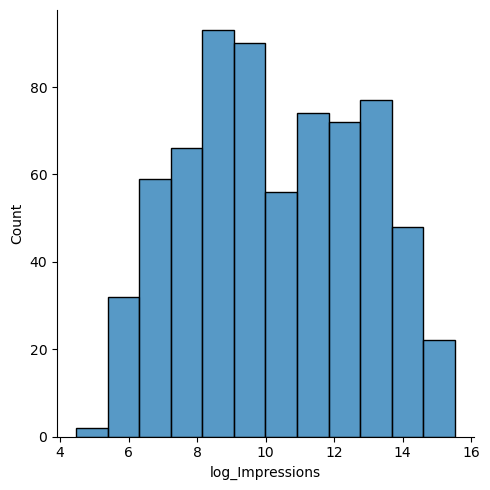

In [23]:
sns.displot(data=impres_by_fb, x="log_Impressions")

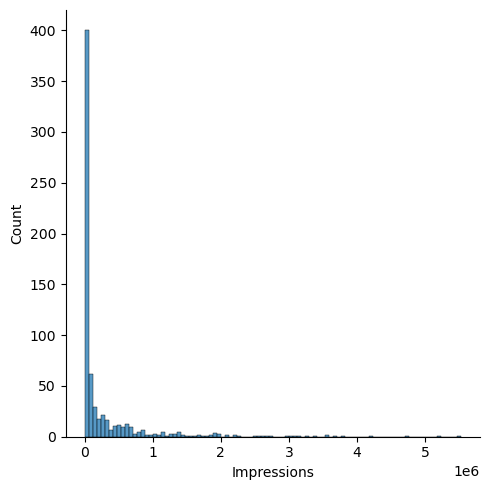

In [24]:
sns.displot(data=impres_by_fb, x="Impressions")


## Расчёт CTR (Click-Through Rate)

Теперь посчитаем ещё несколько полезных метрик.

Первая — `CTR` (*click-through rate*), которая показывает кликабельность рекламы, то есть отношение числа кликов к количеству показов.

Формула:

$$
CTR = \frac{clicks}{impressions}
$$

Необходимо:

- Создать новую колонку `CTR`
- Посмотреть на описательные статистики

Задание

В качестве ответа укажите `ad_id` объявления с наибольшим `CTR`.

In [26]:
conversion.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


In [27]:
conversion['ctr'] = conversion.Clicks / conversion.Impressions

In [31]:
conversion.ctr.describe()

count    1143.000000
mean        0.000164
std         0.000115
min         0.000000
25%         0.000100
50%         0.000160
75%         0.000234
max         0.001059
Name: ctr, dtype: float64

In [39]:
conversion.iloc[conversion.ctr.idxmax(), 0]

np.int64(738637)

## Задание 5

Визуализируйте CTR для каждой из рекламных кампаний (xyz_campaign_id). Какому графику соответствует распределение CTR кампании 916? Для полного визуального совпадения вам понадобится функция sns.distplot(), параметр bins=20 - но можете попробовать и другие варианты функций для гистограмм.

In [43]:
conversion.query('xyz_campaign_id == 916').ctr

/var/folders/xk/r5d7r9yx45q36s025rnh_m7c0000gn/T/ipykernel_83461/2316438021.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a = conversion.query('xyz_campaign_id == 916').ctr, bins = 20, hist= True, kde= False)


<Axes: xlabel='ctr'>

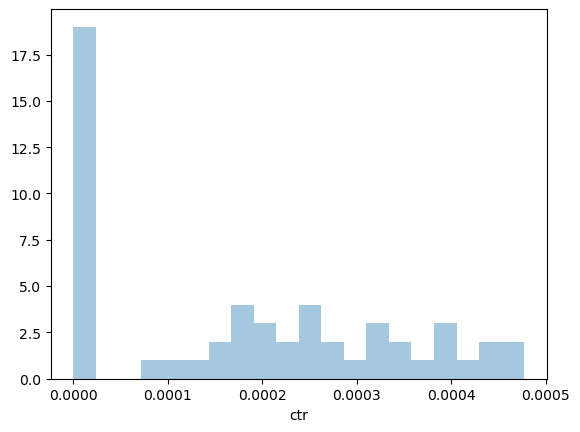

In [47]:
sns.distplot(a = conversion.query('xyz_campaign_id == 916').ctr, bins = 20, hist= True, kde= False)

<Axes: xlabel='ctr', ylabel='Count'>

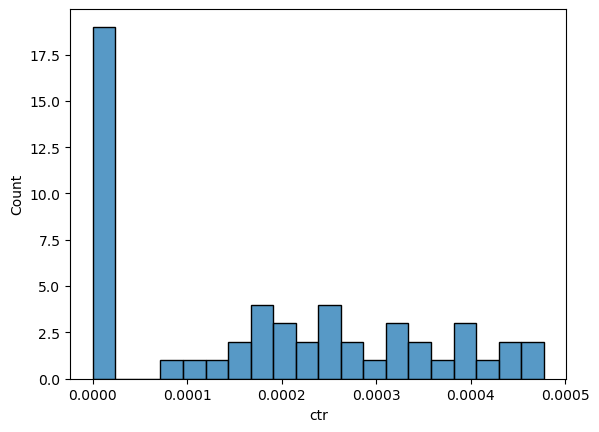

In [48]:
sns.histplot(
    data=conversion.query('xyz_campaign_id == 916'),
    x='ctr',
    bins=20
)

## Задание 6

### Расчёт CPC (Cost-Per-Click)

`CPC` (*cost-per-click*) — стоимость одного клика пользователя по объявлению.

Рассчитывается путём деления суммы потраченных денег на общее число кликов.

Формула:

$$
CPC = \frac{spent}{clicks}
$$

### Необходимо:

- Создать новую переменную `CPC`
- Вывести описательные статистики
- Посмотреть на форму распределения

### Задание

В ответе укажите межквартильный размах (*IQR*), округлённый до двух знаков после точки.

In [49]:
conversion.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,ctr
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1,0.000136
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0,0.000112
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0,0.000000
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0,0.000235
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1,0.000242


In [50]:
conversion['cpc'] = conversion.Spent/conversion.Clicks

In [51]:
conversion.cpc.describe()

count    936.000000
mean       1.499347
std        0.232879
min        0.180000
25%        1.390000
50%        1.498273
75%        1.644364
max        2.212000
Name: cpc, dtype: float64

<Axes: xlabel='cpc', ylabel='Count'>

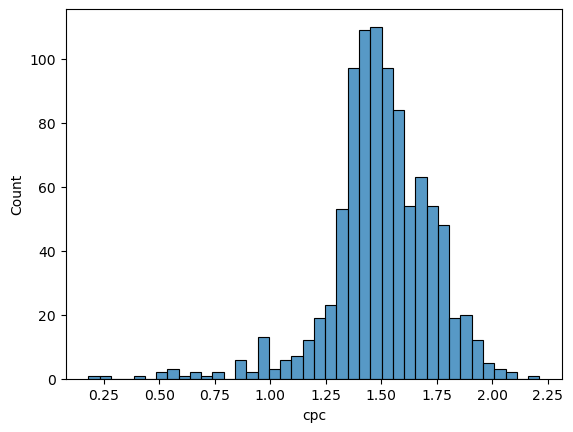

In [54]:
sns.histplot(data = conversion, x = 'cpc')

In [57]:
round(1.644364 - 1.390000, 2)

0.25

In [58]:
round(conversion.cpc.quantile(0.75)-conversion.cpc.quantile(0.25),2)

np.float64(0.25)

## Задание 7

Визуализируйте CPC с разбивкой по полу пользователей, которым были показаны объявления. Какой график получился?



gender
F    Axes(0.125,0.11;0.775x0.77)
M    Axes(0.125,0.11;0.775x0.77)
Name: cpc, dtype: object

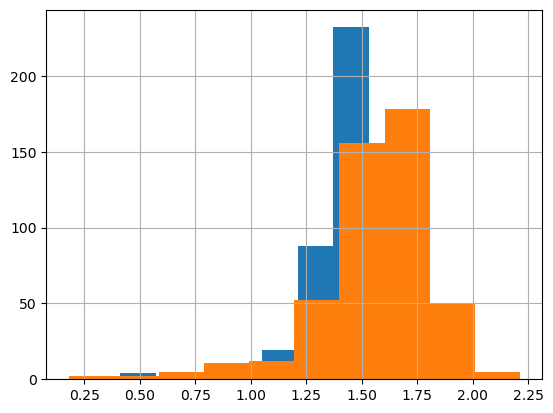

In [59]:
conversion.groupby('gender').cpc.hist()

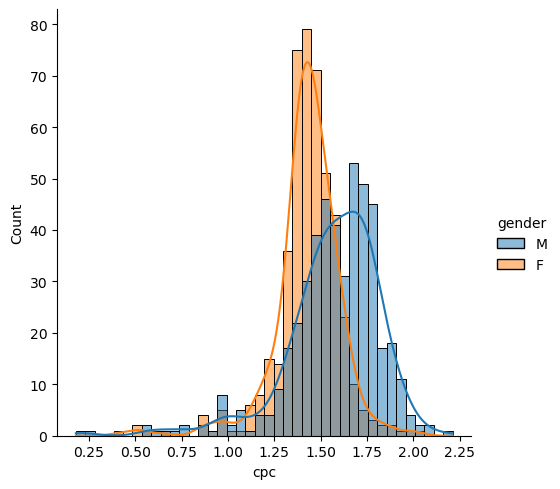

In [61]:
sns.displot(data=conversion, x="cpc", hue="gender", kde = True)


## Задание 8

### Расчёт Conversion Rate (CR)

Конверсия (*conversion rate*) — отношение числа пользователей, совершивших целевое действие на определённом этапе, к общему числу пользователей, дошедших до данного этапа.

Необходимо посчитать конверсию из клика в покупку.

Формула:

$$
CR = \frac{approved\_conversion}{clicks}
$$

### Пример

Если:
- число кликов = `10`
- число покупок = `2`

Тогда:

$$
CR = \frac{2}{10} = 0.2 = 20\%
$$

---

### Задание

В качестве ответа укажите конверсию для объявления `1121814` в процентах, округлив значение до `2` знаков после точки.

Знак процента (`%`) в ответе указывать не нужно.

In [64]:
conversion.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,ctr,cpc
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1,0.000136,1.43
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0,0.000112,0.91
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0,0.000000,NaN
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0,0.000235,1.25
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1,0.000242,1.29


In [73]:
conversion['cr'] = conversion.Approved_Conversion / conversion.Clicks

In [74]:
conversion.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,ctr,cpc,cr
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1,0.000136,1.43,1.0
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0,0.000112,0.91,0.0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0,0.000000,NaN,NaN
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0,0.000235,1.25,0.0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1,0.000242,1.29,1.0


In [78]:
round(conversion.query('ad_id == 1121814').cr * 100, 2)

860    3.09
Name: cr, dtype: float64